<a href="https://colab.research.google.com/github/ilaydacepniogluu-sys/AkademiQ_DataScience/blob/main/AkademiQ_Ders2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#EDA: keşifsel veri analizi (eksik oran hesaplama)

#Model Performansı = Veri kalitesi x Özellik Müh. x model seçimi
# (veri kalitesi en kritik bileşen)  (model seçimi en az önemli olan)

# Garbage in garbage out kuralı

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [ ]:
#matplot ve seaborn pythonun görselleştrime kütüphanesi

#Eksik Veri

NaN doldurma değil.


MCAR ( Missing Copletely At Random) = Bu durumda eksik veri mekanizması tamamen rastgeledir; Yani bir değerin eksik olması, veri setindeki hiçbir değişkenle ilişkili değildir.

 #not: eksik veri bizim dağılımızızı bozmuyorsa boşlukları medyan ile doldurabiliriz.

MAR ( Missing At Random) = MAR durumundaki eksiklik mekanizması gözlemlenebilen diğer değişkenlere bağlıdır. Ancak eksik olan değerin kendisine doğrudan bağlı değildir.

 #burada eksik veriye missing flag ekleyeceğiz.


 MNAR ( Missing Not At Random) = Eksiklik mekanizması direkt eksik değerin kendisiyle ilişkilidir.

  #teknik olarak çözülemez sadece yönetilebilir.

In [ ]:
df = pd.read_csv("ecommerce_synthetic.csv")
df.head()

,musteri_yasi,sehir,cinsiyet,aylik_gelir,toplam_harcama,siparis_sayisi,ortalama_sepet,musteri_id,churn
0,23.0,Sehir_23,Erkek,8049.274797,14535.327035,7.0,258.185054,USR000000,0
1,62.0,Sehir_4,Kadin,89714.014583,8163.295595,16.0,254.973152,USR000001,1
2,55.0,Sehir_75,Kadin,93543.316734,NaN,14.0,131.260394,USR000002,0
3,43.0,Sehir_81,Erkek,24847.354037,4153.712409,9.0,264.570862,USR000003,1
4,NaN,Sehir_92,Erkek,55106.378151,2244.512978,32.0,447.399667,USR000004,0


In [ ]:
sayisal = df.select_dtypes("number").drop(columns="churn")

karsilastirma = pd.DataFrame({
    "mean" : sayisal.mean(),
    "median" : sayisal.median(),
    "oran" : sayisal.mean()/sayisal.median(),
    "skew" : sayisal.skew(),
})
karsilastirma

#skew dağılımın şiddetini ve yönünü gösterir.
#  Oran 1 e ne kadar yaklaşırsa o kadar dengeli bir dağılım var demektir.
#Oran 1 den büyük ise sağa çarpıktır.
#Oran 1 den küçükse sola çarpıklık vardır.

,mean,median,oran,skew
musteri_yasi,45.972421,46.000000,0.999400,0.023048
aylik_gelir,49911.457613,35667.765765,1.399344,4.078571
toplam_harcama,16805.494201,8339.851885,2.015083,4.870924
siparis_sayisi,20.660312,21.000000,0.983824,-0.005164
ortalama_sepet,385.389417,358.383566,1.075355,19.273607


In [ ]:
eksik = df.isnull().mean().mul(100).round(2).rename("eksik_pct")
eksik = eksik[eksik > 0 ].sort_values(ascending=False)
print(eksik.to_string())


#Bu satır bize eksik oran var mı bunu söyleyecek.
#isnull DataFramei bool'a çevirecek yani eksikleri true dolu olanları false olarak göreceğiz.
#Mul dediğimiz ifade true false ifadelerini sayısal yani 1 ve 0 şeklinde görmemizi sağlayacak.
#round(2) dediğimiz ifade 2 basamak yuvarlama yapar. Daha temiz bir çıktı.
#rename dediğimiz ifade ise yeniden adlandırma.
#2.satır kodunda asceding=false dediğimiz yapı büyükten küçüğe sıralama yapmamızı sağlar. Eğer true olsaydı küçükten büyüğe olurdu.
#devam olarak yani hiç eksik olmayan sütunlardan kurtulup büyükten küçüğe sıralama yapar.
#bunlar mul(100) dediğimiz için yüzdelik olarak karşımıza gelecek.

siparis_sayisi    19.22
toplam_harcama     8.74
musteri_yasi       5.00


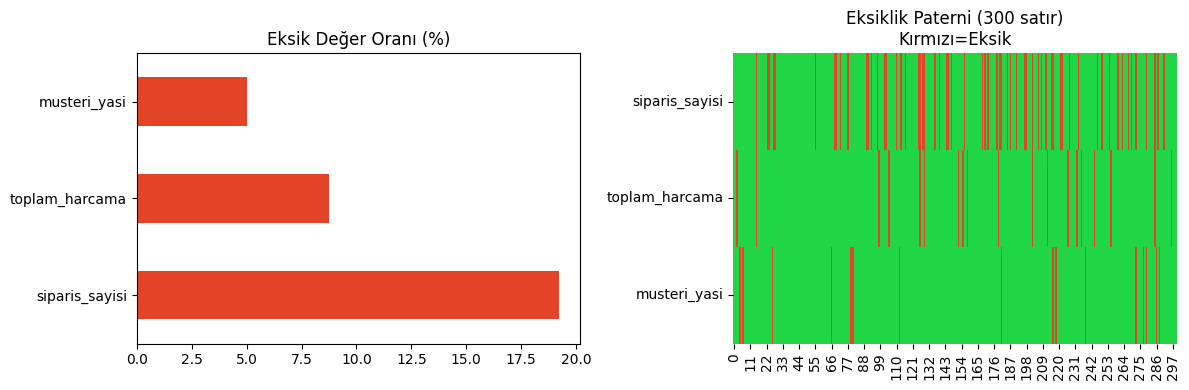

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
eksik.plot(kind="barh", ax =axes[0], color="#e34327")
axes[0].set_title("Eksik Değer Oranı (%)")
#Grafiğin üstünde eksik değer oranı yazacak.

sns.heatmap(
    df[eksik.index].head(300).isnull().T,
    ax=axes[1], cmap=["#20d645","#e34327"] , cbar=False

)
axes[1].set_title("Eksiklik Paterni (300 satır)\nKırmızı=Eksik")
plt.tight_layout() #grafiklerin üst üste binmesini engeller. (çünkü iki grafik var)
plt.show() #grafiği ekrana basar.

#cbar= false renks sklasını kapatır. farklı renkler araya girmesin daha iyi gözüksün

#grafik türü kind ile verilir.
#fig dediğimiz grafiğin kaydedileceği figür.
#axes ise ikili grafik. hem x de hem y de bir grafik göreceğimizi söyler.

In [ ]:
#ikinci tablolarda (müşteri yaşı)kırmızıklıklar(eksiklikler) rastgele dağılmış olsaydı kırmızı çizgiler eşit aralıklarla dağılmış olurdu.
#o yüzden biz buna MCAR diyemeyiz. bu ya MAR dır ya da MNAR dır.

In [ ]:
def siniflandir(df, col):  #df tüm veri setini al, col ise analiz etmek istediğimiz sütunlar.
    eksik_flag=df[col].isnull().astype(int) # sayısal olan sütunları alıp eksik olanları bir alacak dolu olanları sıfır olarak gösterecek.
    sayisal_sutunlar=df.select_dtypes("number").columns.drop(col,errors="ignore") # ilk olarak sayısal sütunları aldık. drop(col) dediğimizde analiz ettiğimiz sütunları kaldırıyoruz. errors=igonere dediğimiz şey ise eğer kolon yok ise hata vermemesi için kullanılır.

#MAR TESTİ
    for x in sayisal_sutunlar:
      mask = df[x].notna() #korelasyon için x sütunu dolu olmak zorunda yoksa korelasyon istatisliği çöker. notna denilen ifade x sütunu boş olmamalı demektir.
      if mask.sum() < 30:  #veri konrolü yapıyoruz. 30 ideal sayıdır. 30 un altına düşülürse gürültüler artar.
       continue

# Minimum veri kontrolü nedir? Bunu neden yapıyoruz?
# Bunu korelasyon testi için yapıyoruz. Eğer elimizde yeterli veri yoksa bu ilişkiyi test etme aşamasına geçmemek için yapılır.
# Korelasyon yapmak için elimizde yeterli veri olması gerekir.
# Aslında şunu yapıyoruz: Eksik olma durumu ile beraber diğer değişken arasında bir ilişki var mı? bunu yapmaya calısıyoruz.


#Korelasyon analizinde p değeri (
#-value), iki değişken arasındaki ilişkinin istatistiksel olarak anlamlı olup olmadığını belirleyen ölçüttür. Korelasyon katsayısı (
#) ilişkinin gücünü ve yönünü söylerken, p değeri bu ilişkinin şans eseri mi oluştuğunu yoksa geneli yansıtan bir gerçek mi olduğunu gösterir.#

      _,p = stats.pointbiserialr(eksik_flag[mask],df.loc[mask,x])   #korelasyonu başlattık. pointbiserialr korelasyon formülünü uygulayan komut.
      if p < 0.05:
        return f"MAR ('{x}' ile ilişkili, p={p:.4f})"

     #MNAR TESTİ #neye bakıyoruz? Eksik veri değerin kendisi yüzünden mi oluşuyor? Eğer değer büyüdükçe ve uç noktalara doğru gittikçe eksiklik artıryorsa MNAR vardır. Eğer bu ilişki yoksa MCAR vardır.

      if col in df.select_dtypes("number").columns:
        tam = df[col].dropna()
        if (df[df[col]>= tam.quantile(0.8)][col].isnull().mean()) > 0.15:
          return "MNAR (uç değerler daha fazla eksik)"

      return "MCAR (rastgele eksiklik)"

    for col in ["musteri_yasi","toplam_harcama", "siparis_sayisi"]:
      pct = df[col].isnull().mean() * 100
      print(f"{col:20s} %{pct:.1f} -> {siniflandir(df,col)}")